In [4]:
# Sales forecasting is an important aspect of business planning, helping organizations predict future sales and make informed decisions about inventory management, marketing strategies and resource allocation. In this article we will explore how to build a sales forecast prediction model using Python. Sales forecasting involves estimating current or future sales based on data trends.
# Importing Required Libraries
# Before starting, ensure you have the necessary libraries installed. For this project, we will be using pandas, matplotlib, seaborn, xgboost and scikit learn. You can install them using pip:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install xgboost
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 3.2 MB/s eta 0:00:32
   ---------------------------------------- 1.0/101.7 MB 2.4 MB/s eta 0:00:42
    --------------------------------------- 1.6/101.7 MB 2.7 MB/s eta 0:00:38
    --------------------------------------- 2.1/101.7 MB 2.6 MB/s eta 0:00:39
   - -------------------------------------- 2.9/101.7 MB 2.6 MB/s eta 0:00:39
   - -------------------------------------- 3.7/101.7 MB 2.8 MB/s eta 0:00:35
   - -------------------------------------- 4.2/101.7 MB 2.7 MB/s eta 0:00:36
   - -------------------------------------- 4.7/101.7 MB 2.8 MB/s eta 0:00:35
   -- ------------------------------------- 5.5/101.7 MB 2.9 MB/s eta 0:00:34
   -- ------------------------------------- 6.0/101.7 MB 2.9 MB/s eta 0:00:34
   -- ------------------------------------- 6.6/101.7 MB 2.8 MB/s eta 0:00:35


In [6]:
# Loading the Dataset
# For this we will be using a sales dataset that contains features like Row ID, Order ID, Customer ID, Customer ID, etc

# Loading the Dataset
file_path = r'C:\Users\paola\OneDrive\Documentos\ML_Exercises\train.csv'
data = pd.read_csv(file_path)

data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


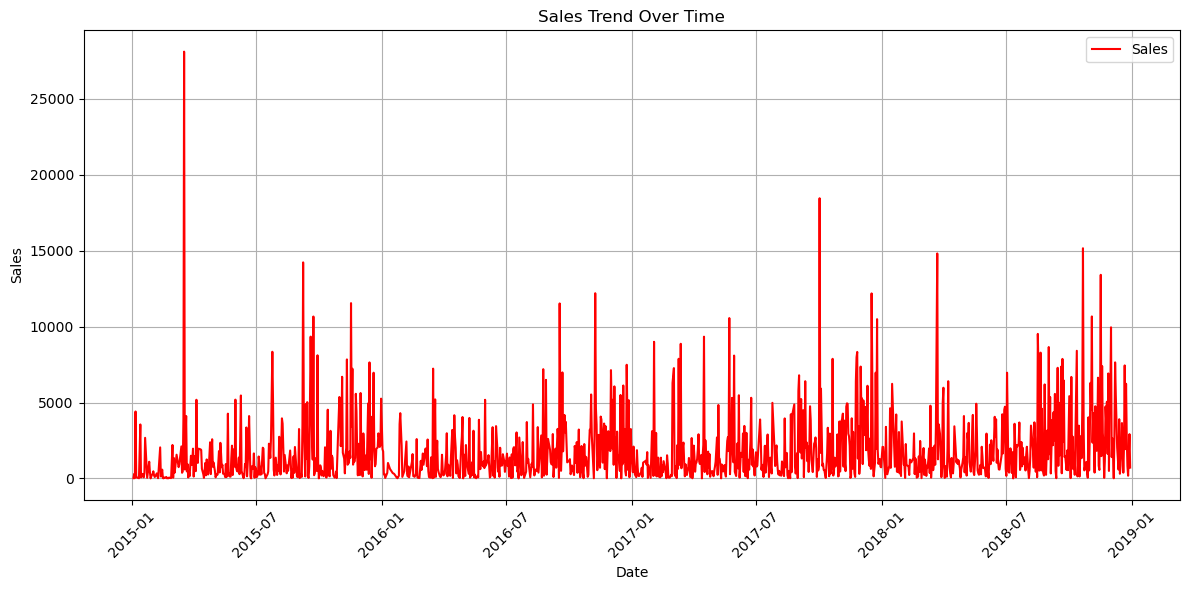

In [7]:
# Data Preprocessing and Visualization
# In this block, we will preprocess the data and visualize the sales trend over time.

# pd.to_datetime: Converts the "Order Date" column into datetime format allowing us to perform time-based operations.
# groupby: Groups the data by "Order Date" and sums the sales for each date, creating a time series of daily sales.

data['Order Date'] = pd.to_datetime(data['Order Date'], format='%d/%m/%Y')

sales_by_date = data.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(sales_by_date['Order Date'], sales_by_date['Sales'], label='Sales', color='red')
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Feature Engineering - Creating Lagged Features
# Here we create lagged features to capture the temporal patterns in the sales data.

# create_lagged_features: This function generates lagged features by shifting the sales data by a given number of time steps like 1, 2, 3, etc. Lag features help the model learn from the previous sales data to predict future sales.
# dropna: Drops rows with missing values which are introduced due to the shift operation when lagging

def create_lagged_features(data, lag=1):
    lagged_data = data.copy()
    for i in range(1, lag+1):
        lagged_data[f'lag_{i}'] = lagged_data['Sales'].shift(i)
    return lagged_data

lag = 5  
sales_with_lags = create_lagged_features(data[['Order Date', 'Sales']], lag)

sales_with_lags = sales_with_lags.dropna()

In [9]:
# Preparing the Data for Training
# In this step we prepare the data for training and testing.

# drop(columns): Removes the 'Order Date' and 'Sales' columns from the feature set X since they are not needed for training as sales is the target variable.
# train_test_split: Splits the dataset into training (80%) and testing (20%) sets.
# shuffle=False: ensures that the data is split in chronological order preserving the time series structure.

X = sales_with_lags.drop(columns=['Order Date', 'Sales'])
y = sales_with_lags['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [10]:
# Training the XGBoost Model

# train the XGBoost model. It is a machine learning algorithm that uses gradient boosting to create highly accurate predictive models particularly well-suited for regression tasks like sales forecasting.

# XGBRegressor: Initializes an XGBoost model for regression tasks.
# objective='reg:squarederror': indicates that we are solving a regression problem i.e predicting continuous sales values.
# learning_rate (lr): Controls the step size at each iteration while moving toward a minimum of the loss function with smaller values leading to slower convergence.
# n_estimators: The number of boosting rounds or trees to build with higher values improving model accuracy but potentially leading to overfitting.
# max_depth: Defines the maximum depth of each decision tree controlling the complexity of the model. Deeper trees can model more complex patterns.
# fit: Trains the model on the training data (X_train, y_train).

model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
model_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [12]:
# Making Predictions and Evaluating the Model
# Here we make predictions and evaluate the model performance using RMSE.

# predict: Makes predictions on the test set (X_test) using the trained XGBoost model.
# mean_squared_error: Computes the Mean Squared Error (MSE) between actual and predicted values. We use np.sqrt to compute the Root Mean Squared Error (RMSE), which is a standard metric for evaluating regression models.

import numpy as np
from sklearn.metrics import mean_squared_error

# Making predictions
predictions_xgb = model_xgb.predict(X_test)

# Calculate RMSE
rmse_xgb = np.sqrt(mean_squared_error(y_test, predictions_xgb))

print(f"RMSE: {rmse_xgb:.2f}")

# The RMSE of 734.63 indicates the average deviation between the actual and predicted sales values. A lower RMSE value signifies better model accuracy, with the model's predictions being closer to the actual sales data. As we have large amount of sales data this RMSE score is accptable.

RMSE: 734.63


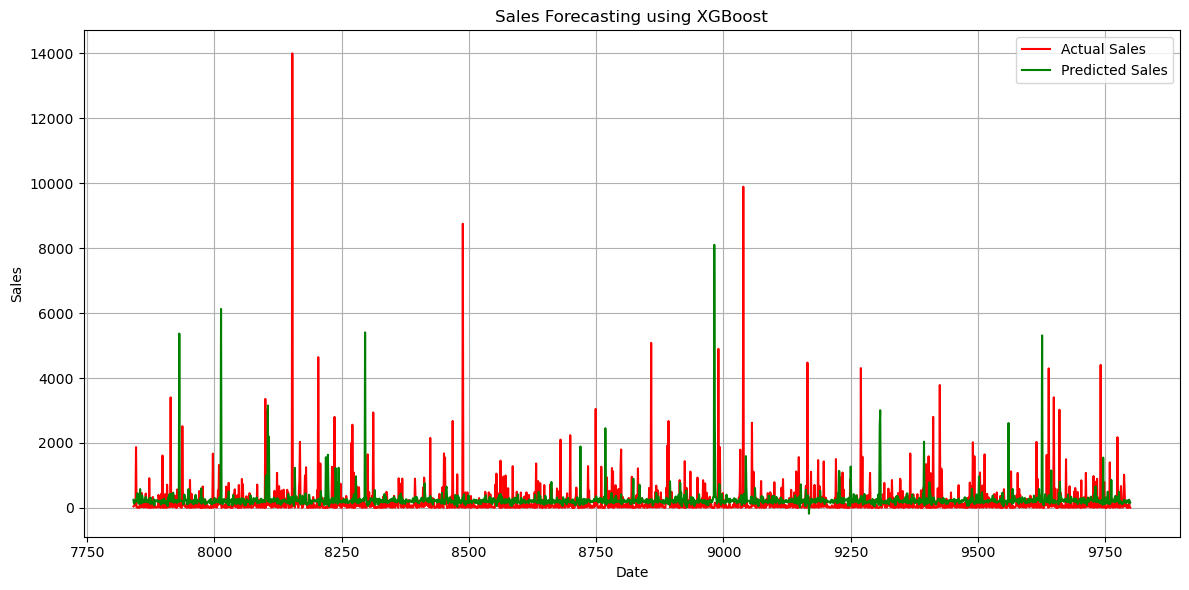

In [13]:
# Visualizing Results
# We will plot both the actual and predicted sales to visually compare the performance of the model.

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Sales', color='red')
plt.plot(y_test.index, predictions_xgb, label='Predicted Sales', color='green')
plt.title('Sales Forecasting using XGBoost')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [15]:
# As we can see the predicted and actual values are quite close to each other this proves the efficiency of our model. Sales forecasting using machine learning models like XGBoost can significantly enhance the accuracy of predictions by capturing temporal patterns in historical data. It can be used for improving sales predictions helping businesses optimize inventory, pricing and demand planning.
# check the current directory
import os
print(os.getcwd())

C:\Users\paola\anaconda_projects\6908ad61-0cd6-4b4a-8513-9e51fcb1a27d


In [1]:
# folder where jupyter is working
import os
os.getcwd()


'C:\\Users\\paola'